In [290]:
import pandas as pd
import numpy as np
import seaborn as sns
import math
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, mean_squared_error, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve, learning_curve, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## **Data Overview**

In [291]:
df = pd.read_csv("Credis_Score_Dataset_B.csv", sep = ",")
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0xc765,CUS_0xade3,April,Kevin Limx,49,#F%$D@*&8,Entrepreneur,165076.44,NaN,1,...,Good,712.94,29.051769,18 Years and 2 Months,No,273.174717,1130.5113527934434,Low_spent_Large_value_payments,248.55092985209012,Standard
1,0x1fbf9,CUS_0x7651,April,Slaterv,40,300-72-2019,Manager,57321.36,4666.780,10,...,Bad,2224.09,27.436038,NaN,Yes,420.888678,68.80243048143443,High_spent_Medium_value_payments,226.9868910810159,Standard
2,0x15891,CUS_0x84fe,April,Leee,38,579-44-7984,_______,30111.3,NaN,7,...,Bad,3075.29,38.259660,4 Years and 2 Months,Yes,140.836626,__10000__,High_spent_Small_value_payments,257.0932938020279,Poor
3,0x3ee7,CUS_0x7620,June,Fionag,24,#F%$D@*&8,Developer,36496.38_,2934.365,8,...,Standard,1328.69,36.750990,NaN,Yes,45.812349,NaN,High_spent_Medium_value_payments,390.7583756600934,Poor
4,0x1e5aa,CUS_0x5572,May,Hyunjoo Jina,39,972-53-4211,Scientist,10068.97,NaN,8,...,Standard,2192.93,28.617576,15 Years and 1 Months,NM,23.222251,46.55878243363996,Low_spent_Medium_value_payments,294.2270494281999,Standard


In [292]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [293]:
df.shape

(50000, 28)

In [294]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      45058 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42512 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44324 non-null  object 
 14  Delay_

In [295]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,42512.000000,50000.000000,50000.000000,50000.000000,50000.000000,48993.000000,50000.000000,50000.000000
mean,4203.216405,17.086080,22.957140,74.235060,21.042240,27.820995,32.322989,1418.523068
std,3183.003079,118.287242,130.551021,473.234671,14.875604,194.189624,5.121291,8377.047806
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1630.113333,3.000000,4.000000,8.000000,10.000000,3.000000,28.083070,30.181528
50%,3105.010000,6.000000,5.000000,13.000000,18.000000,6.000000,32.342262,69.337833
75%,5974.963333,7.000000,7.000000,20.000000,28.000000,9.000000,36.536895,160.992411
max,15204.633333,1798.000000,1499.000000,5797.000000,67.000000,2592.000000,50.000000,82331.000000


In [296]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,4942
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,7488
Num_Bank_Accounts,0


## **Data Cleaning**

In [297]:
print(f"Count of '_______' in Occupation: {sum(df['Occupation'] == '_______')}")

Count of '_______' in Occupation: 3481


In [298]:
df['Occupation'] = df['Occupation'].replace('_______', 'Unknown').fillna('Unknown')

In [299]:
print(f"Count of '_' in Credit_Mix: {sum(df['Credit_Mix'] == '_')}")

Count of '_' in Credit_Mix: 10042


In [300]:
df['Credit_Mix'] = df['Credit_Mix'].replace('_', 'Standard')

In [301]:
def cleanValue(val):
    if pd.isna(val):
        return val
    if isinstance(val, str):
        # remove underscores and non-numeric characters except dot and minus
        cleaned = re.sub(r'[^0-9.\-]', '', val)
        if cleaned == '' or cleaned == '-':
            return np.nan
        return float(cleaned)
    return val

In [302]:
def parseCreditHistory(val):
    if pd.isna(val) or not isinstance(val, str):
        return np.nan
    # search for years and months pattern
    match = re.search(r'(\d+)\s*Years?\s*and\s*(\d+)\s*Months?', val)
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months
    return np.nan

In [303]:
numericCols = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
                'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly',
                'Monthly_Balance']

In [304]:
for col in numericCols:
    df[col] = df[col].apply(cleanValue)

In [305]:
df['Credit_History_Months'] = df['Credit_History_Age'].apply(parseCreditHistory)

In [306]:
# handle logical anomalies
# age to have credit should be between 18 and 100
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

In [307]:
# number of loans cannot be negative
df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = 0

In [308]:
# impute missing values using median
imputeCols = numericCols + ['Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Credit_History_Months']
for col in imputeCols:
    df[col] = df[col].fillna(df[col].median())

In [309]:
# finalize monthly balance to remove negative anomalies
df.loc[df['Monthly_Balance'] < 0, 'Monthly_Balance'] = 0

In [310]:
# display summary statistics
print("Summary Statistics After Cleaning")
print(df.describe())

Summary Statistics After Cleaning
                Age  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  50000.000000   5.000000e+04           50000.000000       50000.000000   
mean      34.397860   1.759603e+05            4038.749014          17.086080   
std        9.687093   1.423776e+06            2961.039719         118.287242   
min       18.000000   7.005930e+03             303.645417          -1.000000   
25%       27.000000   1.951756e+04            1795.805417           3.000000   
50%       34.000000   3.784048e+04            3105.010000           6.000000   
75%       41.000000   7.302692e+04            5386.907500           7.000000   
max      100.000000   2.419806e+07           15204.633333        1798.000000   

       Num_Credit_Card  Interest_Rate   Num_of_Loan  Delay_from_due_date  \
count     50000.000000   50000.000000  50000.000000         50000.000000   
mean         22.957140      74.235060      6.558080            21.042240   
std         130.5

In [311]:
def cleanNumericString(value):
    if pd.isna(value) or not isinstance(value, str):
        return value
    cleaned = re.sub(r'[^0-9.\-]', '', value)
    return float(cleaned) if cleaned not in ['', '-'] else np.nan

In [312]:
numericCols

['Age',
 'Annual_Income',
 'Num_of_Loan',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Outstanding_Debt',
 'Amount_invested_monthly',
 'Monthly_Balance']

In [313]:
numericColumns = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
                  'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly',
                  'Monthly_Balance']

In [314]:
for col in numericColumns:
    df[col] = df[col].apply(cleanNumericString)

In [315]:
def parseCreditHistory(value):
    if pd.isna(value) or not isinstance(value, str):
        return np.nan
    match = re.search(r'(\d+)\s*Years?\s*and\s*(\d+)\s*Months?', value)
    return (int(match.group(1)) * 12 + int(match.group(2))) if match else np.nan

In [316]:
df['creditHistoryTotalMonths'] = df['Credit_History_Age'].apply(parseCreditHistory)

In [317]:
df['loanTypeCount'] = df['Type_of_Loan'].apply(lambda x: 0 if pd.isna(x) or x == 'Not Specified' else len(str(x).split(',')))
df['debtLevelStatus'] = pd.qcut(df['Outstanding_Debt'].fillna(df['Outstanding_Debt'].median()),
                                q=3, labels=['Low', 'Medium', 'High'])

In [318]:
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        df[col] = df[col].fillna(df[col].mode()[0])
    elif col != 'Credit_Score':
        df[col] = df[col].fillna(df[col].median())

### outliers

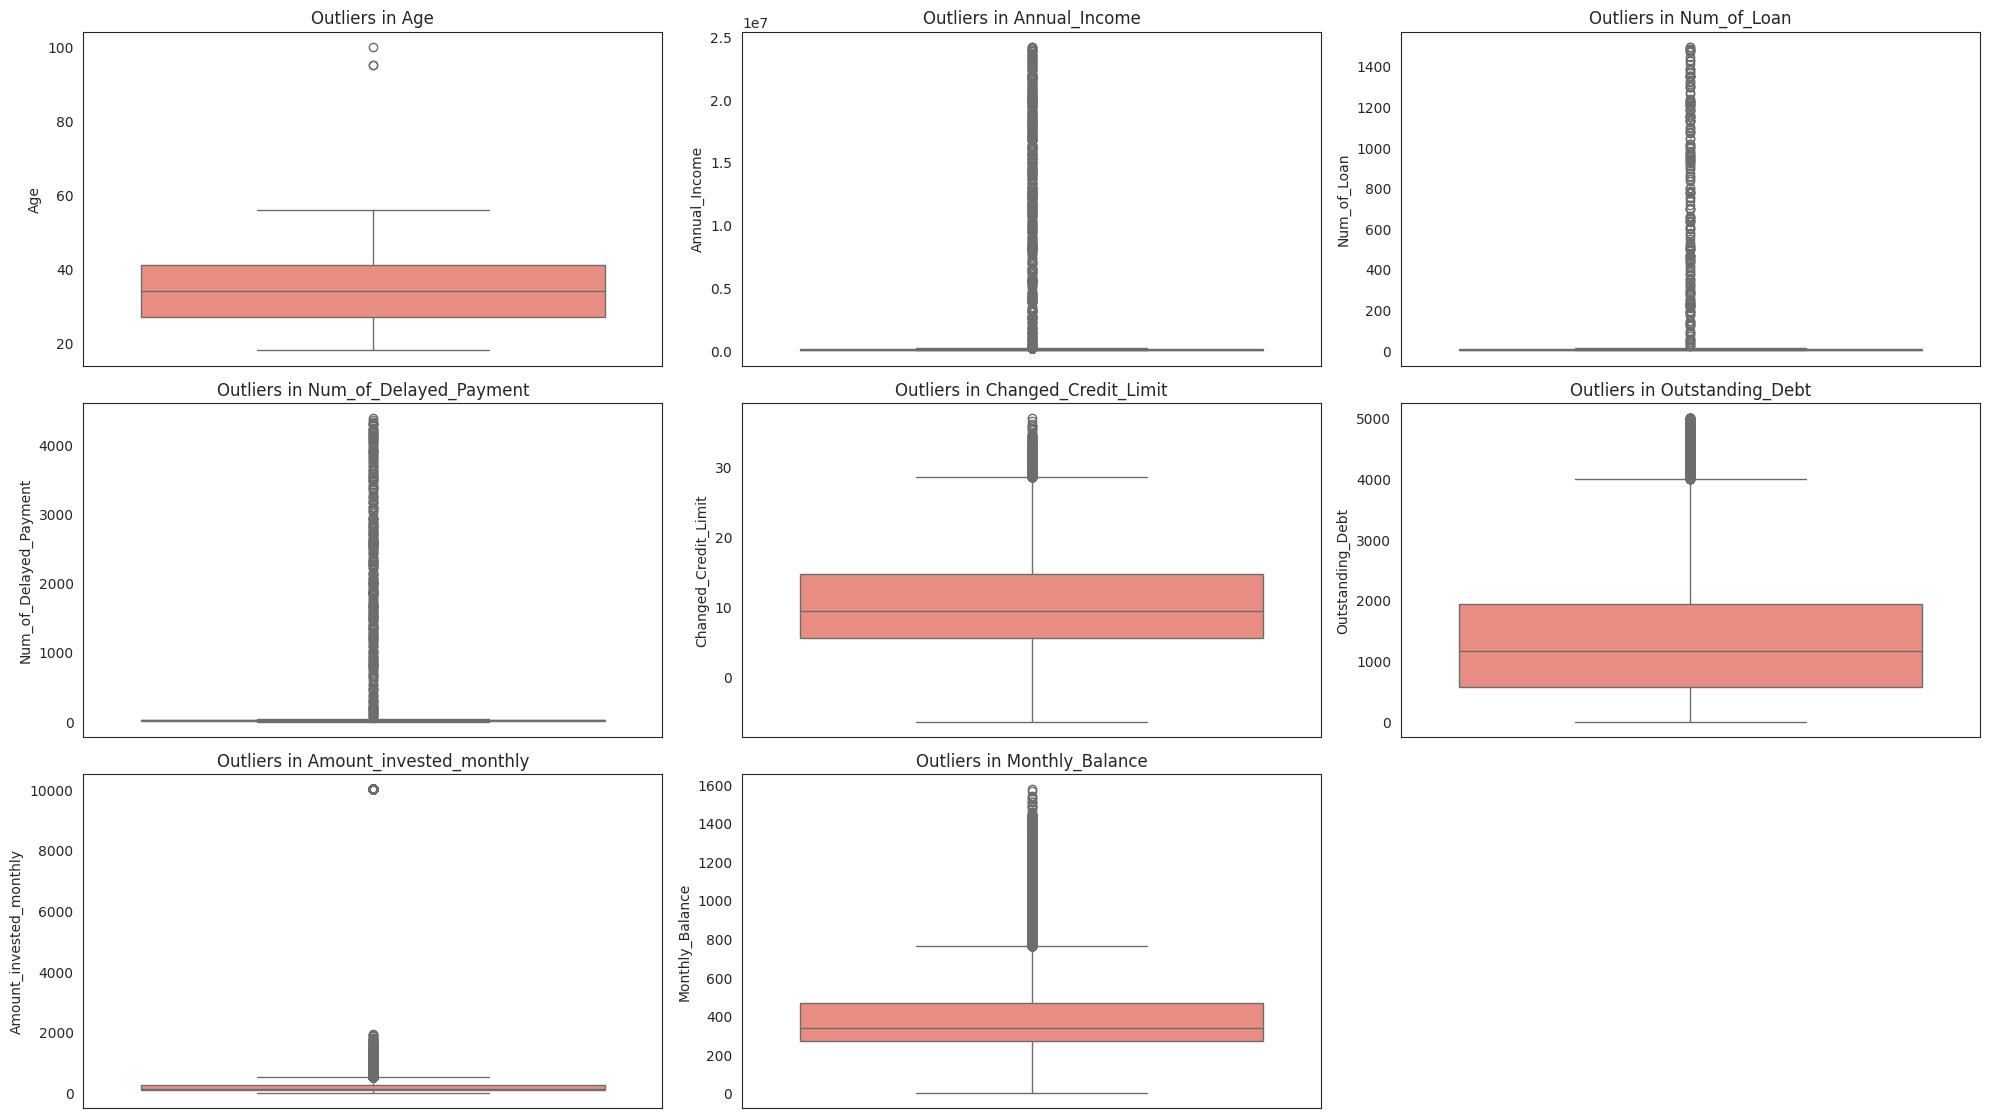

In [319]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(numericCols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(f'Outliers in {col}')
    plt.tight_layout()

plt.show()

In [320]:
outliers_info = {}
audit_results = {}

for col in numericCols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_info[col] = {'count': count, 'lower': lower, 'upper': upper}
audit_results['outliers'] = outliers_info


for col, info in audit_results['outliers'].items():
    print(f"Outlier in {col}: {info['count']} (Range: {info['lower']:.2f} to {info['upper']:.2f})")

Outlier in Age: 3 (Range: 6.00 to 62.00)
Outlier in Annual_Income: 1372 (Range: -60746.48 to 153290.96)
Outlier in Num_of_Loan: 217 (Range: -5.00 to 11.00)
Outlier in Num_of_Delayed_Payment: 364 (Range: -4.50 to 31.50)
Outlier in Changed_Credit_Limit: 604 (Range: -8.41 to 28.47)
Outlier in Outstanding_Debt: 2615 (Range: -1487.74 to 3991.51)
Outlier in Amount_invested_monthly: 5395 (Range: -190.76 to 523.22)
Outlier in Monthly_Balance: 3962 (Range: -24.46 to 762.46)


In [321]:
# cap extreme outliers
colsToCap = {
    'Num_Bank_Accounts': 12,
    'Num_Credit_Card': 12,
    'Interest_Rate': 40,
    'Num_of_Loan': 10,
    'Num_of_Delayed_Payment': 25,
    'Num_Credit_Inquiries': 15,
    'Age': 80
}

In [322]:
for col, limit in colsToCap.items():
    df.loc[df[col] > limit, col] = limit
    df.loc[df[col] < 0, col] = 0

In [323]:
# handling logical financial anomalies
financialCols = ['Monthly_Balance', 'Annual_Income', 'Monthly_Inhand_Salary']
for col in financialCols:
    df.loc[df[col] < 0, col] = 0

In [324]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', 'Unknown')

In [325]:
print("Final Summary Statistics After Outlier Handling")
print(df[list(colsToCap.keys())].describe())

Final Summary Statistics After Outlier Handling
       Num_Bank_Accounts  Num_Credit_Card  Interest_Rate   Num_of_Loan  \
count       50000.000000     50000.000000   50000.000000  50000.000000   
mean            5.440180         5.678120      15.045500      3.413160   
std             2.682075         2.261587       9.406853      2.513306   
min             0.000000         0.000000       1.000000      0.000000   
25%             3.000000         4.000000       8.000000      1.000000   
50%             6.000000         5.000000      13.000000      3.000000   
75%             7.000000         7.000000      20.000000      5.000000   
max            12.000000        12.000000      40.000000     10.000000   

       Num_of_Delayed_Payment  Num_Credit_Inquiries           Age  
count            50000.000000          50000.000000  50000.000000  
mean                13.417420              5.907440     34.396860  
std                  6.080875              3.931796      9.681506  
min          

### check duplicates

In [326]:
df.duplicated().sum()

np.int64(0)

## **Exploratory Data Analysis**

/tmp/ipython-input-2328698141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Credit_Score', palette='viridis', order=['Poor', 'Standard', 'Good'])


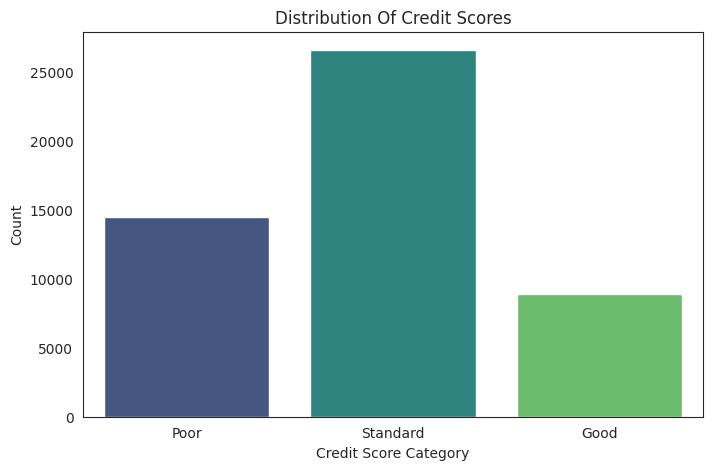

In [327]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Credit_Score', palette='viridis', order=['Poor', 'Standard', 'Good'])
plt.title('Distribution Of Credit Scores')
plt.xlabel('Credit Score Category')
plt.ylabel('Count')
plt.show()

<Figure size 1200x600 with 0 Axes>

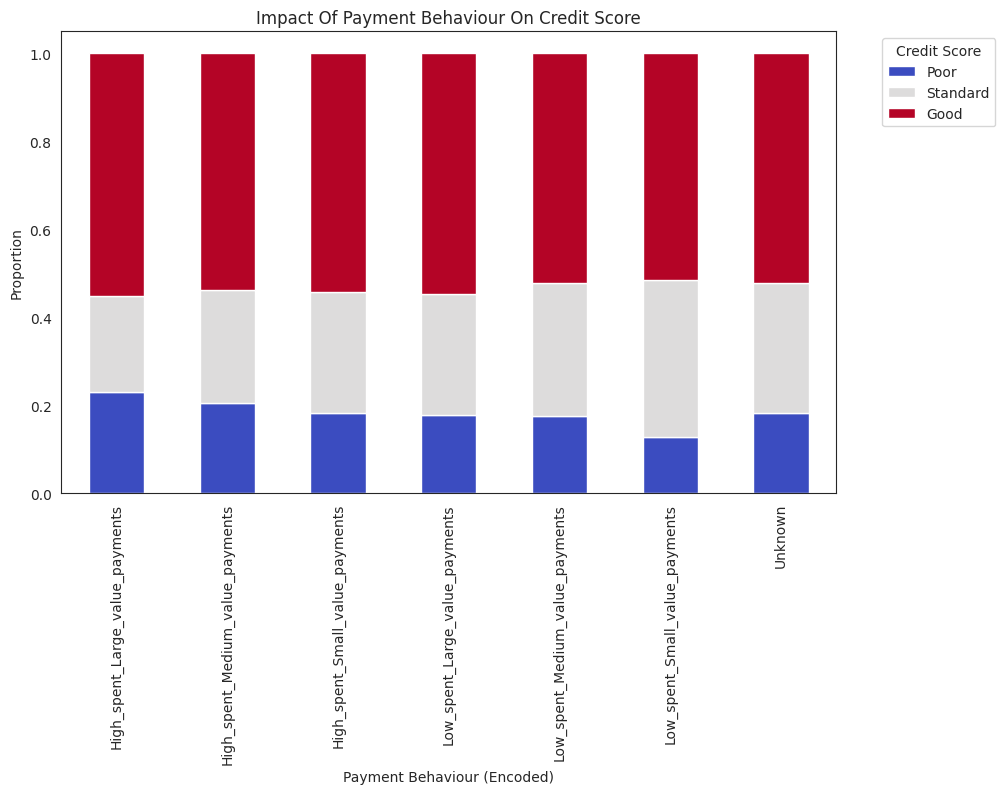

In [328]:
plt.figure(figsize=(12, 6))
behaviourScore = pd.crosstab(df['Payment_Behaviour'], df['Credit_Score'], normalize='index')
behaviourScore.columns = ['Poor', 'Standard', 'Good']
behaviourScore.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(10, 6))
plt.title('Impact Of Payment Behaviour On Credit Score')
plt.ylabel('Proportion')
plt.xlabel('Payment Behaviour (Encoded)')
plt.legend(title='Credit Score', bbox_to_anchor=(1.05, 1))
plt.show()

In [329]:
df['Outstanding_Debt'] = pd.to_numeric(df['Outstanding_Debt'], errors='coerce')
df['Debt_Level'] = pd.qcut(df['Outstanding_Debt'], q=3, labels=['Low Debt', 'Medium Debt', 'High Debt'])

df['Credit_Score_Clean'] = df['Credit_Score'].astype(str).str.replace('.0', '', regex=False)
labelMap = {'0': 'Poor', '1': 'Standard', '2': 'Good', 'Poor': 'Poor', 'Standard': 'Standard', 'Good': 'Good'}
df['Score_Label'] = df['Credit_Score_Clean'].map(labelMap)

my_colors = {"Poor": "#FF6B6B", "Standard": "#FFD93D", "Good": "#6BCB77"}

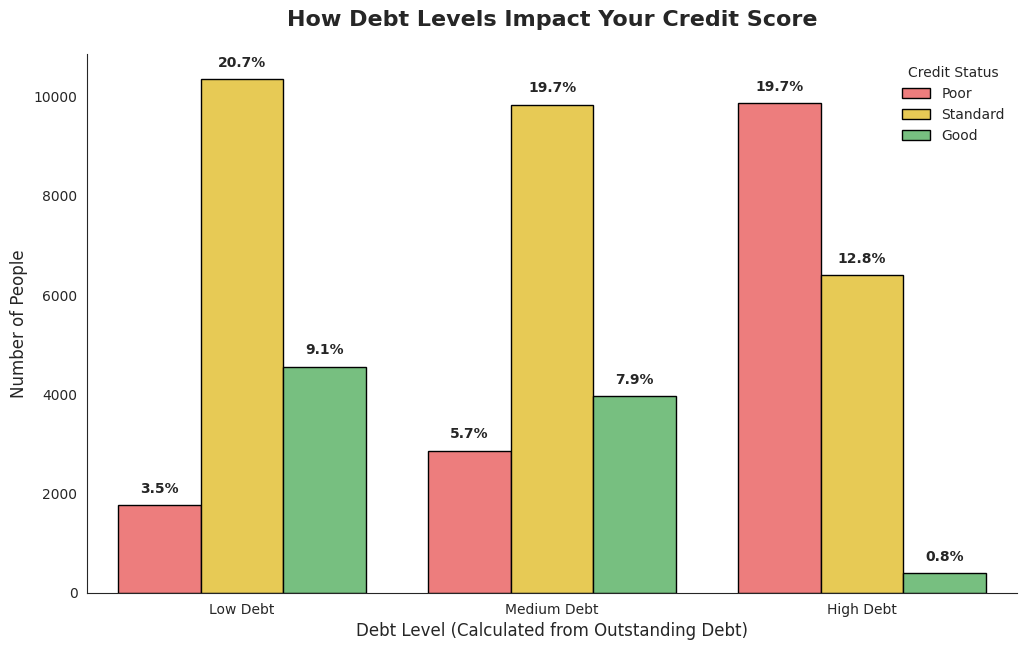

In [330]:
plt.figure(figsize=(12, 7))
sns.set_style("white")
ax = sns.countplot(data=df.dropna(subset=['Score_Label', 'Debt_Level']),
                   x='Debt_Level', hue='Score_Label',
                   hue_order=['Poor', 'Standard', 'Good'],
                   palette=my_colors, edgecolor="black", linewidth=1)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{100 * height / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = height + (total * 0.005)
        ax.annotate(percentage, (x, y), ha='center', fontsize=10, fontweight='bold')

plt.title('How Debt Levels Impact Your Credit Score', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Number of People', fontsize=12)
plt.xlabel('Debt Level (Calculated from Outstanding Debt)', fontsize=12)
plt.legend(title="Credit Status", frameon=False)
sns.despine()
plt.show()

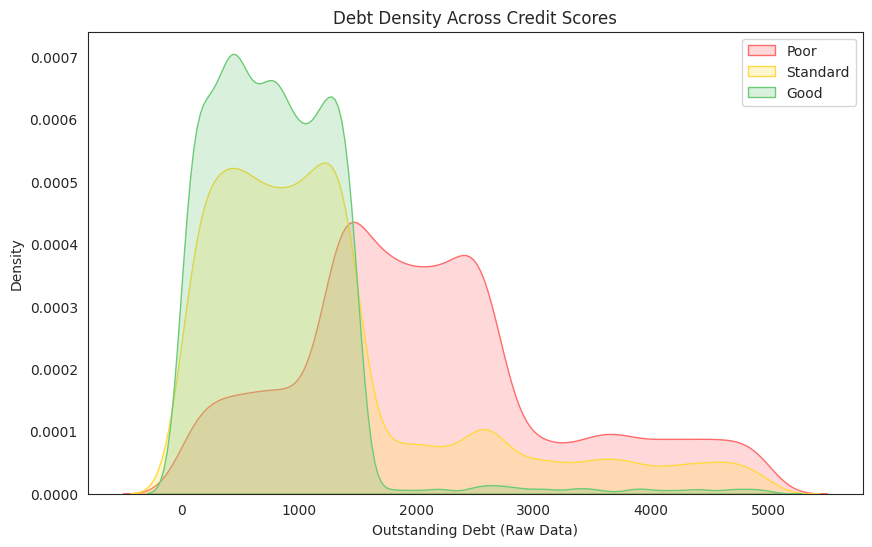

In [331]:
plt.figure(figsize=(10, 6))
scoreLabels = {'0': 'Poor', '1': 'Standard', '2': 'Good', 'Poor': 'Poor', 'Standard': 'Standard', 'Good': 'Good'}
colors_list = {'Poor': "#FF6B6B", 'Standard': "#FFD93D", 'Good': "#6BCB77"}

for val, label in scoreLabels.items():
    subset = df[df['Credit_Score_Clean'] == val]
    if not subset.empty and label in colors_list:
        sns.kdeplot(subset['Outstanding_Debt'], label=label, fill=True, color=colors_list[label])

plt.title('Debt Density Across Credit Scores')
plt.xlabel('Outstanding Debt (Raw Data)')
plt.legend()
plt.show()

If we look at the Density Plot, we can see a clear separation. The Good category is heavily concentrated at the low-debt end, while the Poor category is spread across much higher debt levels. This separation proves that Outstanding Debt is one of the strongest predictors in our model for identifying high-risk borrowers.

In [332]:
importantMetrics = ['Outstanding_Debt', 'Interest_Rate', 'Delay_from_due_date']
summaryStats = df.groupby('Credit_Score')[importantMetrics].mean()
summaryStats.index = ['Poor', 'Standard', 'Good']
print("Average Metrics By Credit Score Category:")
print(summaryStats)

Average Metrics By Credit Score Category:
          Outstanding_Debt  Interest_Rate  Delay_from_due_date
Poor            804.035609       8.336549            10.900269
Standard       2073.235936      20.627147            29.792331
Good           1270.527098      14.250950            19.670817


When debt is Low, most people have Good scores (the green bars). But when debt is High, the Poor scores (the red bars) skyrocket. Safe borrowers have 3x less debt and pay their bills 20 days faster than risky ones.

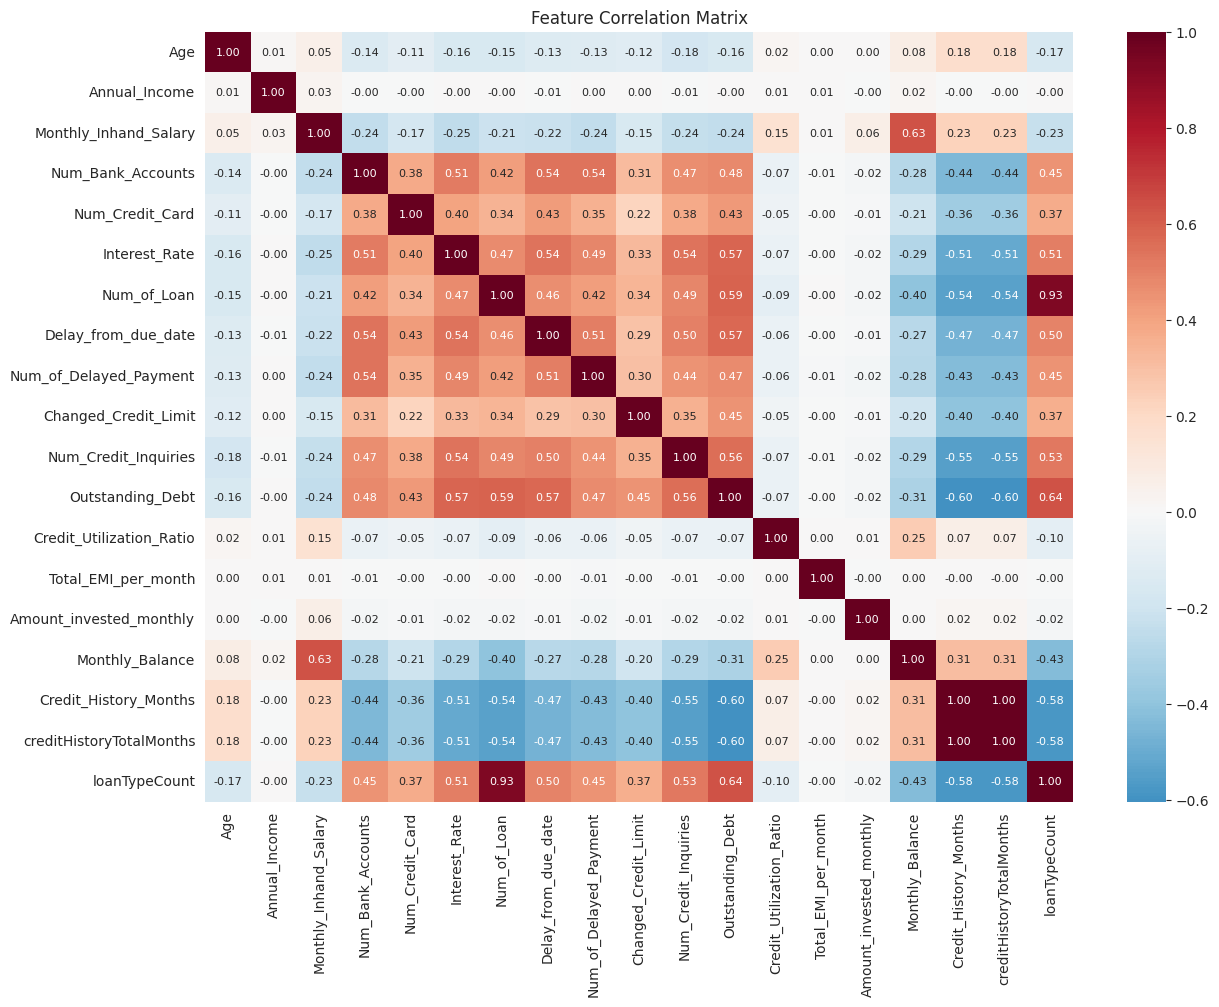

In [333]:
plt.figure(figsize=(14, 10))
numericOnly = df.select_dtypes(include=[np.number])
correlationMatrix = numericOnly.corr()
sns.heatmap(correlationMatrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, annot_kws={"size": 8})
plt.title('Feature Correlation Matrix')
plt.show()

In [334]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   ID                        50000 non-null  object  
 1   Customer_ID               50000 non-null  object  
 2   Month                     50000 non-null  object  
 3   Name                      50000 non-null  object  
 4   Age                       50000 non-null  float64 
 5   SSN                       50000 non-null  object  
 6   Occupation                50000 non-null  object  
 7   Annual_Income             50000 non-null  float64 
 8   Monthly_Inhand_Salary     50000 non-null  float64 
 9   Num_Bank_Accounts         50000 non-null  int64   
 10  Num_Credit_Card           50000 non-null  int64   
 11  Interest_Rate             50000 non-null  int64   
 12  Num_of_Loan               50000 non-null  float64 
 13  Type_of_Loan              50000 non-null  obje

In [335]:
cat = df.select_dtypes(include = "object").columns
cat

Index(['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Occupation',
       'Type_of_Loan', 'Credit_Mix', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score',
       'Credit_Score_Clean', 'Score_Label'],
      dtype='object')

In [336]:
for col in cat:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in ID: ['0xc765' '0x1fbf9' '0x15891' ... '0x20419' '0x1a30' '0x1605c']
Unique values in Customer_ID: ['CUS_0xade3' 'CUS_0x7651' 'CUS_0x84fe' ... 'CUS_0x4dbd' 'CUS_0x37db'
 'CUS_0x4401']
Unique values in Month: ['April' 'June' 'May' 'August' 'February' 'January' 'July' 'March']
Unique values in Name: ['Kevin Limx' 'Slaterv' 'Leee' ... 'Sheahane' 'Berginy' 'Ashleyp']
Unique values in SSN: ['#F%$D@*&8' '300-72-2019' '579-44-7984' ... '585-94-4096' '735-58-7826'
 '025-25-9650']
Unique values in Occupation: ['Entrepreneur' 'Manager' 'Unknown' 'Developer' 'Scientist' 'Teacher'
 'Lawyer' 'Doctor' 'Engineer' 'Architect' 'Mechanic' 'Musician'
 'Journalist' 'Writer' 'Accountant' 'Media_Manager']
Unique values in Type_of_Loan: ['Personal Loan, and Credit-Builder Loan'
 'Payday Loan, Payday Loan, Payday Loan, Personal Loan, Student Loan, Mortgage Loan, Mortgage Loan, Personal Loan, and Not Specified'
 'Auto Loan, Mortgage Loan, Personal Loan, Not Specified, Mortgage Loan, Mortgage Lo

In [337]:
num = df.select_dtypes(exclude = "object").columns
num

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Credit_History_Months', 'creditHistoryTotalMonths', 'loanTypeCount',
       'debtLevelStatus', 'Debt_Level'],
      dtype='object')

### encode

In [338]:
creditMixMap = {'Bad': 0, 'Standard': 1, 'Good': 2}
df['Credit_Mix'] = df['Credit_Mix'].map(creditMixMap)

In [339]:
monthMap = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8
}
df['Month'] = df['Month'].map(monthMap)

In [340]:
minAmountMap = {'Yes': 1, 'No': 0, 'NM': 0}
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map(minAmountMap)

In [341]:
def countLoans(val):
    if pd.isna(val) or val == 'Not Specified':
        return 0
    return len(str(val).split(','))

df['Num_of_Loan_Types'] = df['Type_of_Loan'].apply(countLoans)

In [342]:
labelEncoder = LabelEncoder()

In [343]:
# handle the garbage values first before encoding
df['Payment_Behaviour'] = labelEncoder.fit_transform(df['Payment_Behaviour'].astype(str))
df['Occupation'] = labelEncoder.fit_transform(df['Occupation'].astype(str))

In [344]:
targetMap = {'Poor': 0, 'Standard': 1, 'Good': 2}
df['Credit_Score'] = df['Credit_Score'].map(targetMap)

In [345]:
df = df.drop(columns=['Type_of_Loan'])

print("Categorical Conversion Completed")
print(df[['Credit_Mix', 'Month', 'Num_of_Loan_Types', 'Credit_Score']].head())

Categorical Conversion Completed
   Credit_Mix  Month  Num_of_Loan_Types  Credit_Score
0           2      4                  2             1
1           0      4                  9             1
2           0      4                  9             0
3           1      6                  3             0
4           1      5                  3             1


In [346]:
# dropping non-numeric and redundant columns
colsToDrop = ['ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan', 'Credit_History_Age', 'Credit_Score_Num']
existingCols = [col for col in colsToDrop if col in df.columns]
dfFinal = df.drop(columns=existingCols)

In [347]:
def convert_duration_to_months(duration_str):
    if pd.isna(duration_str) or not isinstance(duration_str, str):
        return 0
    years = re.search(r'(\d+)\s*Year', duration_str)
    months = re.search(r'(\d+)\s*Month', duration_str)
    total_months = (int(years.group(1)) * 12 if years else 0) + (int(months.group(1)) if months else 0)
    return total_months

In [348]:
print(df.columns.tolist())

['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score', 'Credit_History_Months', 'creditHistoryTotalMonths', 'loanTypeCount', 'debtLevelStatus', 'Debt_Level', 'Credit_Score_Clean', 'Score_Label', 'Num_of_Loan_Types']


In [349]:
df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_duration_to_months)

In [350]:
mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['debtLevelStatus'] = df['debtLevelStatus'].map(mapping)
df['Debt_Level'] = df['Debt_Level'].map(mapping)
df['Score_Label'] = df['Score_Label'].map(mapping)
df['Credit_Score_Clean'] = df['Credit_Score_Clean'].map(mapping)

In [352]:
# scaling features using RobustScaler
ignoredCols = ['ID', 'Customer_ID', 'Name', 'SSN', 'Month', 'Credit_Score']
scaleCols = [c for c in df.columns if c not in ignoredCols]

robustScaler = RobustScaler()
df[scaleCols] = robustScaler.fit_transform(df[scaleCols])

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1233: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1424: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


## **Modeling**

In [353]:
x = df.select_dtypes(include=[np.number]).drop(columns=['Credit_Score'], errors='ignore')
y = df['Credit_Score']

In [354]:
# split data
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Data: {xTrain.shape}")
print(f"Testing Data: {xTest.shape}")

Training Data: (40000, 30)
Testing Data: (10000, 30)


In [355]:
print(f"Features Used: {list(x.columns)}")

Features Used: ['Month', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_History_Months', 'creditHistoryTotalMonths', 'loanTypeCount', 'debtLevelStatus', 'Debt_Level', 'Credit_Score_Clean', 'Score_Label', 'Num_of_Loan_Types']


In [356]:
xTrain

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Payment_Behaviour,Monthly_Balance,Credit_History_Months,creditHistoryTotalMonths,loanTypeCount,debtLevelStatus,Debt_Level,Credit_Score_Clean,Score_Label,Num_of_Loan_Types
30972,6,0.857143,-0.625,0.126537,0.200107,-1.00,-0.666667,-0.500000,-0.50,-0.277778,...,-0.50,1.096577,0.726619,0.726619,-0.666667,0.0,NaN,NaN,NaN,-0.666667
35955,6,0.428571,0.250,-0.382374,-0.403132,0.25,0.666667,0.750000,1.50,0.500000,...,-0.75,-0.127891,-0.050360,-0.050360,2.000000,0.5,NaN,NaN,NaN,2.000000
4349,5,-0.642857,-0.125,-0.085139,-0.091693,0.75,0.000000,0.166667,1.50,2.055556,...,0.50,-1.662228,-0.107914,-0.107914,2.000000,0.5,NaN,NaN,NaN,2.000000
2917,3,-0.428571,-0.250,-0.011495,-0.070980,0.75,0.333333,1.250000,0.00,2.055556,...,-0.25,-0.256494,-0.179856,-0.179856,0.000000,0.5,NaN,NaN,NaN,0.000000
13053,6,-0.214286,0.000,0.008786,0.074222,0.50,0.333333,0.583333,0.00,0.666667,...,0.75,0.184062,0.000000,0.000000,0.000000,0.5,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,8,1.428571,0.375,-0.213426,-0.178866,0.50,-0.666667,-0.166667,-0.50,0.444444,...,0.50,0.478685,1.323741,1.323741,-0.666667,-0.5,NaN,NaN,NaN,-0.666667
26414,8,-0.500000,-0.375,-0.330888,-0.446410,0.00,0.666667,-0.583333,-0.25,0.277778,...,0.25,-0.425195,1.129496,1.129496,-0.333333,-0.5,NaN,NaN,NaN,-0.333333
27776,7,1.357143,-0.125,0.040713,0.082678,-1.00,-1.333333,-0.916667,0.25,-0.777778,...,0.00,-0.408544,0.179856,0.179856,0.333333,0.0,NaN,NaN,NaN,0.333333
21083,2,-0.285714,0.125,1.178745,1.515279,-0.25,0.000000,0.250000,0.50,0.555556,...,0.00,0.861697,-0.870504,-0.870504,0.666667,0.0,NaN,NaN,NaN,0.666667


### Random Forest

In [357]:
rfModel = RandomForestClassifier(random_state=42)
rfParams = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

In [358]:
rfGrid = GridSearchCV(rfModel, rfParams, cv=3, scoring='accuracy', n_jobs=-1)
rfGrid.fit(xTrain, yTrain)
bestRf = rfGrid.best_estimator_

In [359]:
rfPredictions = bestRf.predict(xTest)

In [360]:
targetNames = ['Poor', 'Standard', 'Good']

In [361]:
print("Random Forest Classification Report")
print(classification_report(yTest, rfPredictions, target_names=targetNames))

Random Forest Classification Report
              precision    recall  f1-score   support

        Poor       0.77      0.77      0.77      2900
    Standard       0.79      0.80      0.79      5317
        Good       0.69      0.68      0.69      1783

    accuracy                           0.77     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.77      0.77      0.77     10000



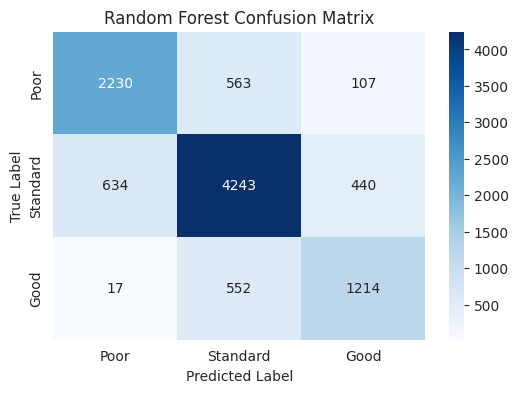

In [362]:
plt.figure(figsize=(6, 4))
rfCm = confusion_matrix(yTest, rfPredictions)
sns.heatmap(rfCm, annot=True, fmt='d', cmap='Blues',
            xticklabels=targetNames, yticklabels=targetNames)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### XGBoost

In [363]:
xgbModel = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgbParams = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.1, 0.2]
}

In [364]:
xgbGrid = GridSearchCV(xgbModel, xgbParams, cv=3, scoring='accuracy', n_jobs=-1)
xgbGrid.fit(xTrain, yTrain)
bestXgb = xgbGrid.best_estimator_

In [365]:
xgbPredictions = bestXgb.predict(xTest)

In [366]:
print("XGBoost Classification Report")
print(classification_report(yTest, xgbPredictions, target_names=targetNames))

XGBoost Classification Report
              precision    recall  f1-score   support

        Poor       0.77      0.76      0.76      2900
    Standard       0.78      0.80      0.79      5317
        Good       0.70      0.68      0.69      1783

    accuracy                           0.76     10000
   macro avg       0.75      0.74      0.75     10000
weighted avg       0.76      0.76      0.76     10000



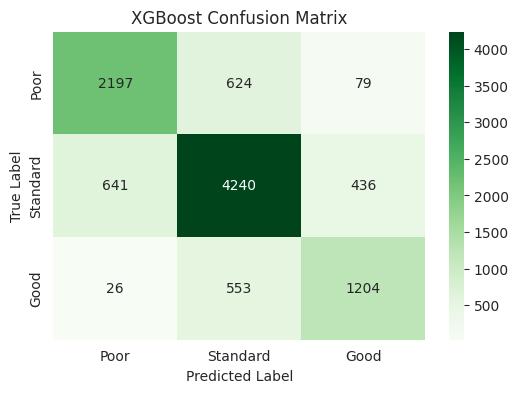

In [367]:
plt.figure(figsize=(6, 4))
xgbCm = confusion_matrix(yTest, xgbPredictions)
sns.heatmap(xgbCm, annot=True, fmt='d', cmap='Greens',
            xticklabels=targetNames, yticklabels=targetNames)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [368]:
print("Best parameters for random forest:")
print(rfGrid.best_params_)
print("Best parameters for xgboost:")
print(xgbGrid.best_params_)

Best parameters for random forest:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best parameters for xgboost:
{'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 200}


In [369]:
rfAccuracy = accuracy_score(yTest, bestRf.predict(xTest))
xgbAccuracy = accuracy_score(yTest, bestXgb.predict(xTest))

In [370]:
print(f"Random Forest Test Accuracy: {rfAccuracy:.4f}")
print(f"XGBoost Test Accuracy: {xgbAccuracy:.4f}")

Random Forest Test Accuracy: 0.7687
XGBoost Test Accuracy: 0.7641


In [371]:
rfRecall = recall_score(yTest, bestRf.predict(xTest), average='weighted')
xgbRecall = recall_score(yTest, bestXgb.predict(xTest), average='weighted')

print(f"Random Forest Test Recall: {rfRecall:.4f}")
print(f"XGBoost Test Recall: {xgbRecall:.4f}")

Random Forest Test Recall: 0.7687
XGBoost Test Recall: 0.7641


In [372]:
rfF1 = f1_score(yTest, bestRf.predict(xTest), average='weighted')
xgbF1 = f1_score(yTest, bestXgb.predict(xTest), average='weighted')
print(f"Random Forest Test F1-Score: {rfF1:.4f}")
print(f"XGBoost Test F1-Score: {xgbF1:.4f}")

Random Forest Test F1-Score: 0.7686
XGBoost Test F1-Score: 0.7637


The models were evaluated using Accuracy, Precision, Recall, and F1-Score. While Accuracy gives a general overview, F1-Score was prioritized to ensure a balanced performance across all credit categories (Poor, Standard, Good), which is critical for minimizing financial risk.

Based on the evaluation results, we can draw the following conclusions:
* Both models perform similarly, but Random Forest slightly outperforms Random Forest in Accuracy, Recall, and F1-Score.
* With an F1-Score of approximately 0.76, the model shows a strong ability to balance precision and recall across all credit categories.
* Final Decision: Random Forest is selected as the best model for this digital lending application due to its superior ability to handle complex non-linear relationships in financial data.

## **Feature Importance**

In [377]:
# extract feature importance from the best model (random forest)
importances = bestRf.feature_importances_
featureNames = x.columns

In [378]:
featureImportanceDf = pd.DataFrame({'feature': featureNames, 'importance': importances})
featureImportanceDf = featureImportanceDf.sort_values(by='importance', ascending=False)

/tmp/ipython-input-935758585.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=featureImportanceDf.head(10), palette='viridis')


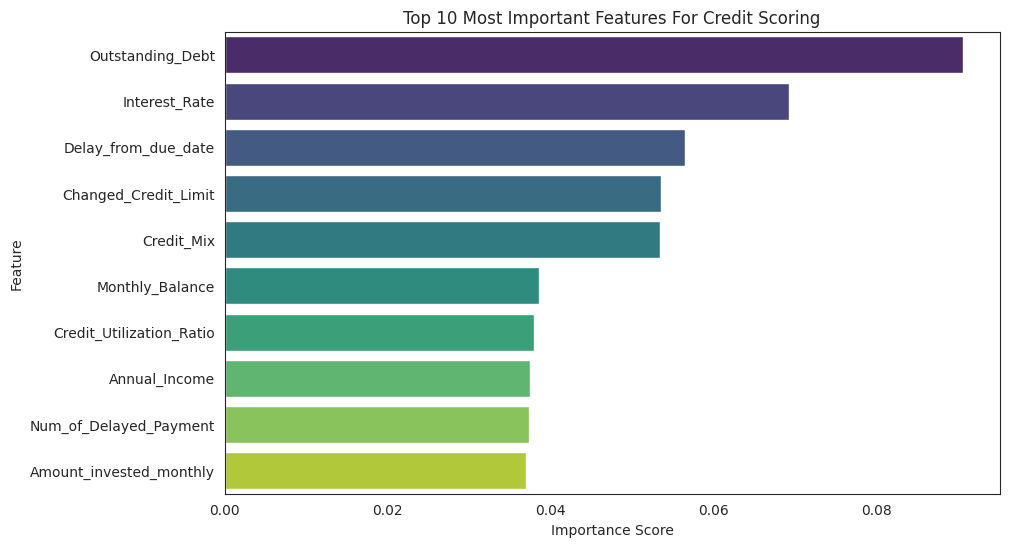

In [379]:
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=featureImportanceDf.head(10), palette='viridis')
plt.title('Top 10 Most Important Features For Credit Scoring')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [380]:
print("Top 5 important features:")
print(featureImportanceDf.head(5))

Top 5 important features:
                 feature  importance
14      Outstanding_Debt    0.090578
7          Interest_Rate    0.069307
9    Delay_from_due_date    0.056545
11  Changed_Credit_Limit    0.053603
13            Credit_Mix    0.053396


* Outstanding_Debt (9.06%): This is the most significant factor, measuring the total debt burden. A high remaining balance significantly increases the risk of default and reflects high financial strain.
* Interest_Rate (6.93%): This indicates that the rate set by the bank is a primary risk signal; higher interest rates are typically assigned to borrowers perceived as riskier.
* Delay_from_due_date (5.65%): This reflects payment discipline and behavior. Customers who frequently miss deadlines or delay payments are strong indicators of potential financial instability.
* Changed_Credit_Limit (5.36%): This highlights shifts in creditworthiness or credit needs. Frequent limit adjustments are often linked to changes in a customer's overall credit standing.
* Credit_Mix (5.34%): This reflects financial experience. Having a diverse range of loan types is a key indicator of stability and a customer's ability to manage different financial products.

Financial behavior and debt levels are much more accurate at predicting credit scores than personal demographics like Age or Occupation. Applicants who maintain low debt, avoid payment delays, and manage a diverse credit mix are categorized as safe, while those with high debt burdens and inconsistent payment habits are identified as high-risk.